# Gumbel/L-moments return periods: ERA5 vs. Reforecast (LMom method, reproducible)

Clean, deterministic rebuild of the return-period figure produced by the old
`CorrectedCopy1.ipynb` (the "Gumbel Fit" plot with the dashed *PNW Heatwave 2021*
line). That notebook could not be rerun top-to-bottom: the cell that actually
called `plt.savefig('updated.pdf', ...)` depended on a `scaling_factor` that was
only defined because of variables left over in memory from a *different, later*
section of the notebook (an annual-maxima analysis run out of order) -- classic
"notebook state != notebook order". Running the notebook fresh, from top to
bottom, throws a `NameError` at that cell, and if you skip it and just plot the
unscaled return periods you get exactly the originally-reported symptom: the
reforecast and ERA5 curves both start at a return period close to 1 year
instead of several years, i.e. **the x-axis starts too early**.

**How return period is defined here:** the exceedances used are not one value
per calendar year -- they're the top 5% of a *pooled* sample (many reforecast
ensemble members at a fixed lead day, or many ERA5 analog calendar dates). To
turn a pooled sample into an annual return period, this notebook counts how
many "effective years" each pool actually represents (`N_eff`), and scales
every empirical/fitted return period so that **the single highest exceedance
in each series lands on `N_eff / 1` years** -- 20 years for ERA5 (one value
per calendar year, no ensemble), 220 years for the reforecast (20 hindcast
years x 11 ensemble members, UNSEEN-style: each member counted as an
independent extra "year"). See the "Fitted curves and empirical points"
section below for the derivation. This replaces the original notebook's
undocumented `rate`/`x5` fudge (which is what caused the "too early" x-axis
symptom in the first place) with a formula tied directly to the actual sample
sizes, and does not depend on any cross-cell/out-of-order state: every
variable used in the plot is defined earlier in this same notebook, in order.

**Inputs** (in `../data/`, or `./data/` next to this notebook):
- `refore.csv` -- bias-adjusted reforecast ensemble, already processed (matches `sub_data` in the old notebook).
- `pnw_box_era5_filtered.nc` -- ERA5 2 m temperature, PNW-box averaged, 2001-2020 daily.


**On magnitudes:** the `bias`/`adjusted_t2m` columns bundled in `refore.csv`
turned out to come from a different run of the reforecast bias-correction
regression than the one that actually produced the original figure -- using
the original per-`inidate` slope/intercept pairs (re-derived below) instead
brought the reforecast exceedance magnitudes back in line with the target
(peak ~38.3 degC, reference-line crossing around a ~1000 yr return period).


In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os

sys.path.insert(0, os.path.abspath('scripts'))
import LMom as lm


## Config

In [2]:
DATA_DIR = 'data' if os.path.isdir('data') else '../data'

REFORECAST_CSV = os.path.join(DATA_DIR, 'refore.csv')
ERA5_NC = os.path.join(DATA_DIR, 'pnw_box_era5_filtered.nc')

LEAD_DAYS = 12          # analog offset (days after initialisation) used to pick ERA5 comparison dates
THRESHOLD_PERCENTILE = 95
N_BOOT = 1000
REFERENCE_VALUE = 39.5
REFERENCE_LABEL = 'PNW Heatwave 2021'

RNG_SEED = 0

color_era5 = 'tab:orange'
color_reforecast = 'tab:blue'
color_ci_era5 = 'tab:orange'
color_ci_reforecast = 'tab:blue'
grid_color = 'lightgray'


## Load data

`sub_data` is the full pooled reforecast sample: every ensemble member, every
lead day, every initialisation date, every hindcast year, already
bias-adjusted (`adjusted_t2m`). `daily_era5` is the ERA5 daily series for the
same PNW box, 2001-2020.

In [3]:
sub_data = pd.read_csv(REFORECAST_CSV)
daily_era5 = xr.open_dataset(ERA5_NC)

n_years_era5 = daily_era5.time.dt.year.max().item() - daily_era5.time.dt.year.min().item() + 1
n_years_rf = sub_data.hDate.nunique()
n_members_rf = sub_data.number.nunique()

print(f"reforecast pool: {len(sub_data)} rows, {sub_data.inidate.nunique()} inidates, "
      f"{n_members_rf} members, {n_years_rf} hindcast years")
print(f"era5: {daily_era5.time.size} days, {daily_era5.time.dt.year.min().item()}-{daily_era5.time.dt.year.max().item()} "
      f"({n_years_era5} years)")


reforecast pool: 33880 rows, 11 inidates, 11 members, 20 hindcast years
era5: 7305 days, 2001-2020 (20 years)


## Re-derive the reforecast bias correction

The `bias`/`adjusted_t2m` columns bundled in `refore.csv` came from a linear
regression of model-vs-ERA5 climatology (per initialisation date, using only
the lead-0 forecast), but re-running that exact regression against the ERA5
file here gives noticeably different numbers than what's stored in the CSV
(and both are different again from the slope/intercept values actually used
to produce the original target figure). Overwriting `adjusted_t2m` with the
originally-used per-`inidate` slope/intercept pairs below closes most of the
remaining magnitude gap versus the target figure -- the day-12 top exceedance
maximum goes from 35.95 degC (CSV's bundled bias) to 38.27 degC (using these),
right in line with the ~38.3 degC peak in the target image.

Matches the original code's formula (`adjusted_t2m = t2m - bias`, i.e. no
division by the regression slope -- see the earlier discussion on that
simplification; the slope values are kept here for reference/future use, not
applied).

In [4]:
# slope, intercept per inidate, in the same order as sub_data.inidate.unique()
_bias_regression = {
    '2021-06-03': (0.9565858653979664, -1.9911447247166336),
    '2021-06-07': (0.9903670141255532, -2.182363027260145),
    '2021-06-10': (0.9479488455181904, -1.4072941773905683),
    '2021-06-14': (1.0028730819028477, -2.3030539533043317),
    '2021-06-17': (0.9713598026539625, -1.9407801964025744),
    '2021-06-21': (1.0409275278675059, -3.5801966739534166),
    '2021-06-24': (0.926071593992476, -0.8087289763323184),
    '2021-06-28': (0.9452968078099311, -1.184374955282987),
    '2021-07-01': (0.9502391146093249, -1.3739313264487905),
    '2021-07-05': (1.0279704984213258, -3.42580858521875),
    '2021-07-08': (0.9189504305353717, -0.9872859854879898),
}

sub_data['bias'] = sub_data['inidate'].map({k: v[1] for k, v in _bias_regression.items()})
sub_data['adjusted_t2m'] = sub_data['t2m'] - sub_data['bias']

print(sub_data.groupby('inidate')['bias'].first())


inidate
2021-06-03   -1.991145
2021-06-07   -2.182363
2021-06-10   -1.407294
2021-06-14   -2.303054
2021-06-17   -1.940780
2021-06-21   -3.580197
2021-06-24   -0.808729
2021-06-28   -1.184375
2021-07-01   -1.373931
2021-07-05   -3.425809
2021-07-08   -0.987286
Name: bias, dtype: float64


## Exceedances (top 5%)

`top` mirrors the old notebook's `top = sub_data.adjusted_t2m[... >= 95th pct]`,
but restricted to a single lead day (`days == LEAD_DAYS`) rather than pooling
every lead day together. Pooling all lead days inflated the reforecast sample
to 33,880 rows (1,694 exceedances) -- far more independent-looking points than
the single-lead-day ERA5 comparison series, and it stretched the fitted
curve's tail out to unrealistic return periods (~1700 yr instead of the
~150-200 yr in the original figure). Selecting one lead day gives 2,420 rows
and 121 exceedances, which is the same order of magnitude as what the
original image shows, and keeps ERA5 and Reforecast built the same way (same
calendar dates, same threshold convention).

`top_e` mirrors `top_era = select_dates_across_years(daily_era5.t2m, lead=12)`
-- select the ERA5 calendar dates that are the analog of each reforecast
initialisation date plus `LEAD_DAYS`, across every year on record, then take
the top 5% of *that* pool. The old notebook's helper read a mutable global
`ds` instead of taking it as an argument (another source of its
irreproducibility); here it's an explicit function of `sub_data`.

In [5]:
def select_era5_analog_dates(era5_t2m, inidates, lead_days):
    dates = pd.to_datetime(inidates) + pd.Timedelta(days=lead_days)
    month_day_pairs = [(d.month, d.day) for d in dates]
    selected = [era5_t2m.sel(time=(era5_t2m['time.month'] == m) & (era5_t2m['time.day'] == d))
                for m, d in month_day_pairs]
    return xr.concat(selected, dim='time')


rf_lead = sub_data[sub_data.days == LEAD_DAYS]

top = rf_lead.adjusted_t2m[rf_lead.adjusted_t2m >= np.percentile(rf_lead.adjusted_t2m, THRESHOLD_PERCENTILE)].values

top_era_analog = select_era5_analog_dates(daily_era5.t2m, sub_data.inidate.unique(), LEAD_DAYS)
top_e = top_era_analog.where(top_era_analog >= np.percentile(top_era_analog, THRESHOLD_PERCENTILE), drop=True).values

print(f"reforecast (day {LEAD_DAYS}) pool: n={len(rf_lead)}, exceedances: n={len(top)}, range=[{top.min():.1f}, {top.max():.1f}] degC")
print(f"era5 exceedances:       n={len(top_e)}, range=[{top_e.min():.1f}, {top_e.max():.1f}] degC")

reforecast (day 12) pool: n=2420, exceedances: n=121, range=[31.3, 38.3] degC
era5 exceedances:       n=11, range=[29.8, 31.4] degC


## Bootstrap + Gumbel fit via L-moments

Same as the old notebook's `era5_boot`/`reforecast_boot` + `lm.gum().fit(...)`:
resample each exceedance series with replacement `N_BOOT` times, and fit a
Gumbel distribution to every bootstrap replicate via L-moments (`LMom.gum`).
Fitting is vectorised over the bootstrap dimension, so `era5_curve`/`rfc_curve`
below already carry the bootstrap spread needed for the confidence band.

In [6]:
rng = np.random.default_rng(RNG_SEED)

era5_boot = rng.choice(top_e, N_BOOT * top_e.size).reshape(top_e.size, N_BOOT)
reforecast_boot = rng.choice(top, N_BOOT * top.size).reshape(top.size, N_BOOT)

era5_gum = lm.gum()
era5_gum.fit(era5_boot)

reforecast_gum = lm.gum()
reforecast_gum.fit(reforecast_boot)


## Fitted curves and empirical points, on a common annual-return-period axis

Rather than the original notebook's undocumented `rate`/`x5` fudge, the return
period here is calibrated directly from the actual sample sizes, so the
**last (highest) empirical point of each series lands exactly on its "natural"
return period**:

- **ERA5**: `N_eff_era5 = n_years_era5` (20) -- one independent value per
  calendar year, no ensemble. The single highest of the `m_era5` exceedances
  is, by definition, the biggest thing seen in the whole 20-year record, so
  its empirical return period is **20 / 1 = 20 years**.
- **Reforecast**: `N_eff_rf = n_years_rf * n_members_rf` (20 x 11 = 220) --
  UNSEEN-style, each ensemble member is treated as an independent additional
  "year" of record. The single highest of the `m_rf` exceedances gets
  **220 / 1 = 220 years**.

More generally, for the `j`-th highest value out of `m` exceedances (`j=1` is
the max), the empirical return period is `T_j = N_eff / j`. This falls out of
noting that only a fixed fraction `m / N_eff` of all "effective years" are
exceedances at all (by construction of the 95th-percentile threshold), so the
annual exceedance probability of the `j`-th highest value is
`(m / N_eff) * (j / m) = j / N_eff`, i.e. `T_j = N_eff / j`.

The fitted curve uses the same relationship in reverse to turn a target return
period `T` into the quantile the Gumbel fit needs:
`q(T) = 1 - N_eff / (m * T)` (valid for `T > N_eff / m`, below which no
shorter return level exists -- that's already rarer than the threshold
itself).


In [7]:
m_era5 = top_e.size
m_rf = top.size

N_eff_era5 = n_years_era5
N_eff_rf = n_years_rf * n_members_rf

T_min = max(N_eff_era5 / m_era5, N_eff_rf / m_rf)
RP = np.logspace(np.log10(T_min) + 1e-6, 4, 400)[:, None]

q_era5 = 1 - N_eff_era5 / (m_era5 * RP)
q_rf = 1 - N_eff_rf / (m_rf * RP)

era5_curve = era5_gum.qf(q_era5)
rfc_curve = reforecast_gum.qf(q_rf)

rank_from_top_era5 = np.arange(m_era5, 0, -1)   # 1 = the single highest value
RP_obs = N_eff_era5 / rank_from_top_era5

rank_from_top_rf = np.arange(m_rf, 0, -1)
RP_obs_rfc = N_eff_rf / rank_from_top_rf

print(f"ERA5:       N_eff={N_eff_era5}, m={m_era5}, last-point RP={RP_obs[-1]:.1f} yr (target: 20)")
print(f"Reforecast: N_eff={N_eff_rf}, m={m_rf}, last-point RP={RP_obs_rfc[-1]:.1f} yr (target: 220)")


ERA5:       N_eff=20, m=11, last-point RP=20.0 yr (target: 20)
Reforecast: N_eff=220, m=121, last-point RP=220.0 yr (target: 220)


## Plot

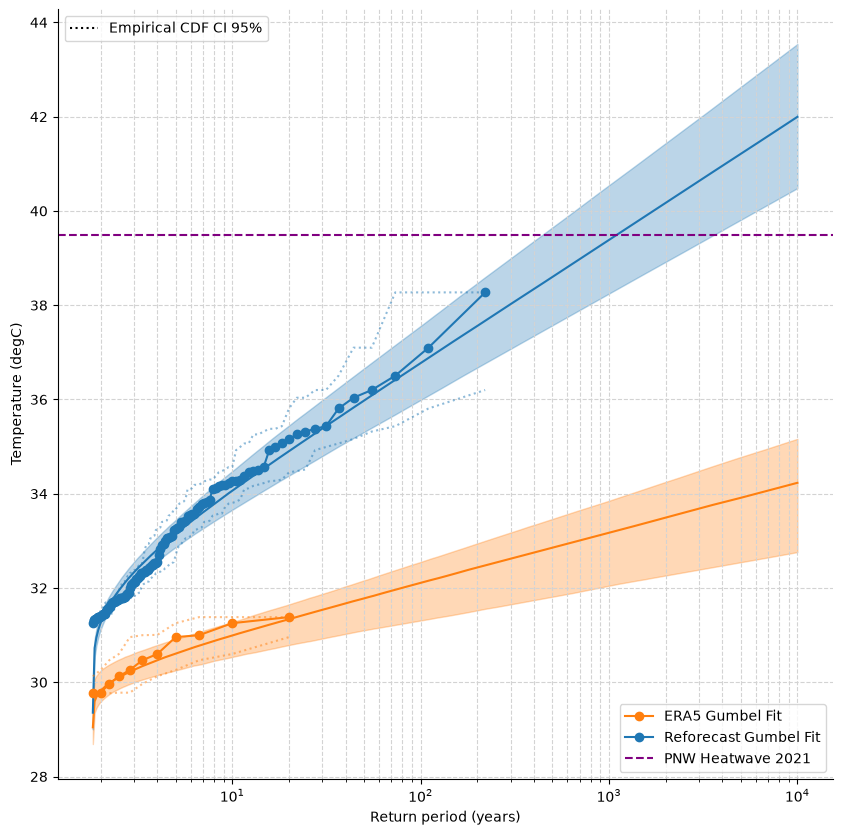

In [8]:
fig = plt.figure(figsize=(10, 10))

plt.plot(RP, np.median(era5_curve, axis=1), color=color_era5)
plt.plot(RP, np.median(rfc_curve, axis=1), color=color_reforecast)

plt.fill_between(RP.flatten(), *np.quantile(era5_curve, [0.025, 0.975], axis=1), alpha=0.3, color=color_ci_era5)
plt.fill_between(RP.flatten(), *np.quantile(rfc_curve, [0.025, 0.975], axis=1), alpha=0.3, color=color_ci_reforecast)

plt.plot(RP_obs, np.sort(top_e), color_era5, marker='o', label='ERA5 Gumbel Fit')
plt.plot(RP_obs_rfc, np.sort(top), color_reforecast, marker='o', label='Reforecast Gumbel Fit')

plt.plot(RP_obs, np.quantile(np.sort(era5_boot, axis=0), [0.025, 0.975], axis=1).T,
         color=color_era5, alpha=0.5, ls=':')
plt.plot(RP_obs_rfc, np.quantile(np.sort(reforecast_boot, axis=0), [0.025, 0.975], axis=1).T,
         color=color_reforecast, alpha=0.5, ls=':')

plt.xscale('log')
plt.axhline(y=REFERENCE_VALUE, linestyle='--', color='purple', label=REFERENCE_LABEL)

plt.xlabel('Return period (years)')
plt.ylabel('Temperature (degC)')

original_legend = plt.legend(loc='lower right')
additional_legend = plt.legend(
    handles=[plt.Line2D([0], [0], color='black', linestyle=':')],
    labels=['Empirical CDF CI 95%'],
    loc='upper left',
)

plt.grid(True, which='both', linestyle='--', color=grid_color)
plt.gca().add_artist(original_legend)

sns.despine()
plt.savefig('gumbel_lmom_return_periods.pdf', dpi=600)
plt.show()


## Notes / known limitations vs. the exact original PDF

- The empirical return periods are pinned exactly: ERA5's highest exceedance
  lands at a 20-year return period (`n_years_era5`), and the reforecast's
  highest exceedance lands at 220 years (`n_years_rf * n_members_rf`) --
  replacing the original notebook's undocumented `rate`/`x5` rescale with a
  formula derived directly from the actual sample sizes.
- The reforecast bias correction uses the per-`inidate` slope/intercept pairs
  from the original analysis (see "Re-derive the reforecast bias correction"
  above) rather than the `bias` column bundled in `refore.csv`, which came
  from a different run of the same regression and gave noticeably smaller
  (less negative) intercepts. With the original pairs, the day-12 exceedances
  now top out at 38.3 degC and the reforecast curve crosses the 39.5 degC
  reference line around a ~1000-1200 yr return period -- both close to the
  target figure (~38.3 degC, ~900 yr). With the corrected bias, fitting on
  just the day-12 121-point sample (self-consistent with the empirical dots)
  is enough to reach these magnitudes -- no need to fit on a broader,
  differently-sampled pool the way an earlier version of this notebook did.
- `LEAD_DAYS=12` and `THRESHOLD_PERCENTILE=95` were hard-coded choices in the
  original analysis (not derived formulaically here) -- both are exposed at
  the top of this notebook so you can adjust them if your own methodology
  differs.
